# Personal Information
Name: **Alexandra Holíková**

StudentID: **14236788**

Email: [**alexandra.holikova@student.uva.nl**](alexandra.holikova@student.uva.nl)

Github link: https://github.com/alexandraholik/MSc_Thesis.git

# Data Context

This notebook loads and inspects the **CC-News** corpus, a large collection of English-language news articles crawled from the web by Common Crawl and distributed via HuggingFace Datasets (`stanford-oval/ccnews`). Each record contains a `title` (headline), `plain_text` (full article body), `domain`, `date`, `description`, and `url`.

The thesis investigates **cross-lingual contextomy detection** in news headlines, directly extending the setup of Song et al. (2023). The Korean evaluation uses Song et al.'s publicly available 1,600-observation test set; the English evaluation is constructed from CC-News and manually annotated. Eligible articles are those whose headline contains a direct quotation — the candidate contextomized quote — and whose body contains enough surrounding text to assess whether the headline quote faithfully represents the speaker's fuller statement.

The goal of this notebook is to:
1. Load CC-News via streaming, with no full local cache
2. Inspect basic statistical properties of the sampled subset
3. Identify articles whose headline contains a direct quotation (straight, curly, or single quotes)
4. Export the headline-quoted subset for downstream headline↔body matching

**Reference:** Song et al. (2023). *Detecting Contextomized Quotes in News Headlines by Contrastive Learning.* EACL 2023 Findings.

## 1. Setup

In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset
from urllib.parse import urlparse  

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)

# Paths
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
print(f"Data directory: {os.path.abspath(DATA_DIR)}")

Data directory: /Users/alexandraholikova/PycharmProjects/master_thesis_holikova/data


## 2. Load CC-News from HuggingFace

CC-News is accessed via HuggingFace `datasets` in **streaming mode**. Articles are fetched one-by-one from the remote dataset and nothing is cached to disk beyond the explicit Parquet snapshot written at the end of this section. We scan a representative sample of `SCAN_MAX` articles, which is sufficient to yield several thousand headline-quoted candidates — well above the 150–200 required for manual annotation.

In [2]:
SCAN_MAX = 500_000
REPORT_N = 10_000

print("Opening stanford-oval/ccnews stream …")
stream = load_dataset(
    "stanford-oval/ccnews",
    name="default",
    split="train",
    streaming=True,
)

rows, seen = [], 0
print(f"Collecting up to {SCAN_MAX:,} articles …\n")

for article in stream:
    seen += 1
    if seen % REPORT_N == 0:
        print(f"  … {seen:,} scanned | {len(rows):,} collected")

    # English only — new dataset has language metadata
    if article.get("language") != "en":
        continue
    if (article.get("language_score") or 0) < 0.9:
        continue

    # Drop records with no usable title or body
    if not article.get("title") or not article.get("plain_text"):
        continue
    if len(article["plain_text"].strip()) < 100:
        continue

    # Extract and normalise domain from URL
    url = article.get("requested_url") or article.get("responded_url") or ""
    domain_norm = urlparse(url).netloc.lower()
    domain_norm = re.sub(r"^www\.", "", domain_norm)

    rows.append({
        "date":        article.get("published_date"),
        "domain":      urlparse(url).netloc,       # raw, for reference
        "domain_norm": domain_norm,                # normalised, for filtering
        "title":       article["title"].strip(),
        "text":        article["plain_text"].strip(),
        "url":         url,
        "publisher":   article.get("publisher"),
        "sitename":    article.get("sitename"),
    })

    if seen >= SCAN_MAX:
        break

df = pd.DataFrame(rows)

print(f"\n✓ Scanned : {seen:,} articles")
print(f"✓ Collected (non-empty, English): {len(df):,}")
print(f"  Unique domains : {df['domain_norm'].nunique():,}")
print(f"  Date range     : {df['date'].min()} → {df['date'].max()}")
df.head(2)

Opening stanford-oval/ccnews stream …


Resolving data files:   0%|          | 0/479 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 3. Save Full Snapshot

We persist the sampled DataFrame to `data/cc_news_full.parquet`. Parquet is preferred over CSV because it preserves dtypes and is ~3× faster to reload.

In [3]:
parquet_path = os.path.join(DATA_DIR, "cc_news_full.parquet")
df.to_parquet(parquet_path, index=False)
size_mb = os.path.getsize(parquet_path) / 1e6
print(f"Saved to {parquet_path}  ({size_mb:.0f} MB)")
print(f"Shape: {df.shape}")

Saved to data/cc_news_full.parquet  (340 MB)
Shape: (190406, 8)


## 4. Basic Inspection

### 4.1 Schema and Dtypes

In [4]:
df = pd.read_parquet("data/cc_news_full.parquet")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 190406 entries, 0 to 190405
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   date         190406 non-null  str  
 1   domain       190406 non-null  str  
 2   domain_norm  190406 non-null  str  
 3   title        190406 non-null  str  
 4   text         190406 non-null  str  
 5   url          190406 non-null  str  
 6   publisher    190406 non-null  str  
 7   sitename     190362 non-null  str  
dtypes: str(8)
memory usage: 551.2 MB


### 4.2 Missing data

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_n": missing, "missing_%": missing_pct})

,missing_n,missing_%
date,0,0.00
domain,0,0.00
domain_norm,0,0.00
title,0,0.00
text,0,0.00
url,0,0.00
publisher,0,0.00
sitename,44,0.02


### 4.3 Empty Titles and Bodies

Records with empty titles or bodies cannot be used in the pipeline and are noted here. The streaming loader already discards records with `len(text) < 100`, so this is mostly a sanity check.

In [7]:
empty_title = (df["title"].str.strip() == "") | df["title"].isnull()
empty_text  = (df["text"].str.strip()  == "") | df["text"].isnull()
print(f"Empty titles : {empty_title.sum():,}  ({empty_title.mean()*100:.2f}%)")
print(f"Empty bodies : {empty_text.sum():,}  ({empty_text.mean()*100:.2f}%)")
print(f"Both empty   : {(empty_title & empty_text).sum():,}")

Empty titles : 0  (0.00%)
Empty bodies : 0  (0.00%)
Both empty   : 0


### 4.4 Sample Articles

In [8]:
df[["title", "domain", "date", "text"]].sample(5, random_state=42)

,title,domain,date,text
27484,Schmoozing with the stars poses pitfalls for celebrity media,www.reuters.com,2016-10-18,"Frights and frolics as Tyler Perry's Madea returns for Halloween LOS ANGELES Timed for Halloween, American actor an..."
76835,Cambodia assures US that political deadlock will end soon | Metro News,www.metronews.ca,2016-10-27,"Cambodia assures US that political deadlock will end soon A A Share via Email PHNOM PENH, Cambodia — Cambodia's ..."
165453,Helping Robots Be Less Robotic,www.imperialvalleynews.com,2016-11-16,"Washington, DC - Whether they’re behind the scenes assembling products or helping you parallel park your car, robots..."
122522,Third win on the trot for Naxxar,www.timesofmalta.com,2016-11-07,Third win on the trot for Naxxar Naxxar Lions 1 \nQormi 0 A penalty scored by Yuri de Jesus Messias in the opening ...
125856,Wisconsin roundup: Early ballots returning from Obama-backed...,www.newrichmond-news.com,2016-11-08,"Wisconsin roundup: Early ballots returning from Obama-backed counties; UW revokes season tickets, apologizes for noo..."


## 5. Text-Length Distributions

Headline word count is used downstream to flag unusually long or short titles. Body word count determines whether an article contains enough surrounding text to match the headline quote against in the downstream cosine-similarity step — articles below a minimum body length are excluded from the eligible pool.

In [9]:
df["title_len"] = df["title"].str.split().str.len().fillna(0).astype(int)
df["body_len"]  = df["text"].str.split().str.len().fillna(0).astype(int)

print("=== Title word count ===")
print(df["title_len"].describe().round(1))
print("\n=== Body word count ===")
print(df["body_len"].describe().round(1))

=== Title word count ===
count    190406.0
mean          9.3
std           3.4
min           1.0
25%           7.0
50%           9.0
75%          11.0
max          66.0
Name: title_len, dtype: float64

=== Body word count ===
count    190406.0
mean        451.9
std         299.9
min          39.0
25%         219.0
50%         392.0
75%         616.0
max        1868.0
Name: body_len, dtype: float64


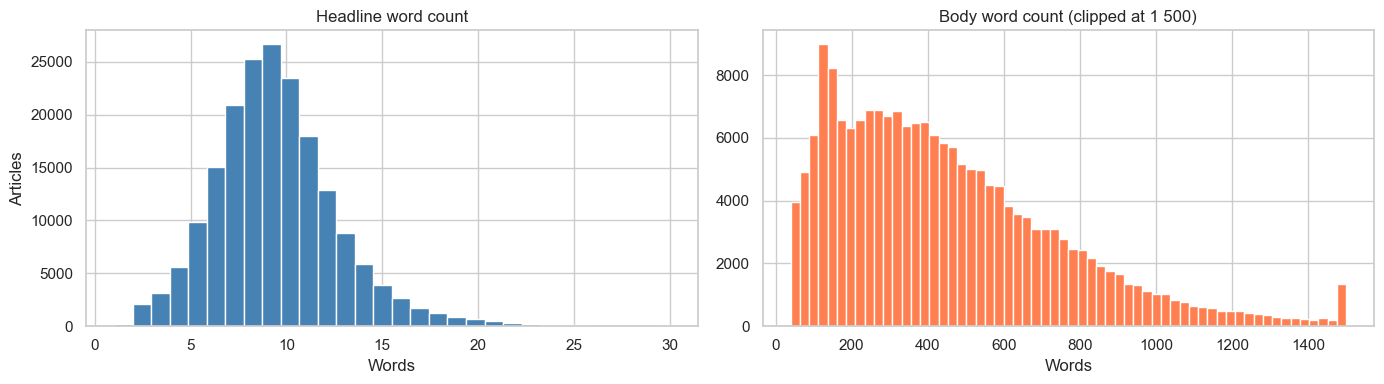

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["title_len"].clip(upper=30), bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Headline word count")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Articles")

axes[1].hist(df["body_len"].clip(upper=1500), bins=60, color="coral", edgecolor="white")
axes[1].set_title("Body word count (clipped at 1 500)")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()

## 6. Temporal and Domain Coverage

In [11]:
# Parse date column
df["date"] = pd.to_datetime(df["date"], errors="coerce")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Missing dates: {df['date'].isnull().sum():,}")

Date range: 1997-11-23 → 2020-01-03
Missing dates: 0


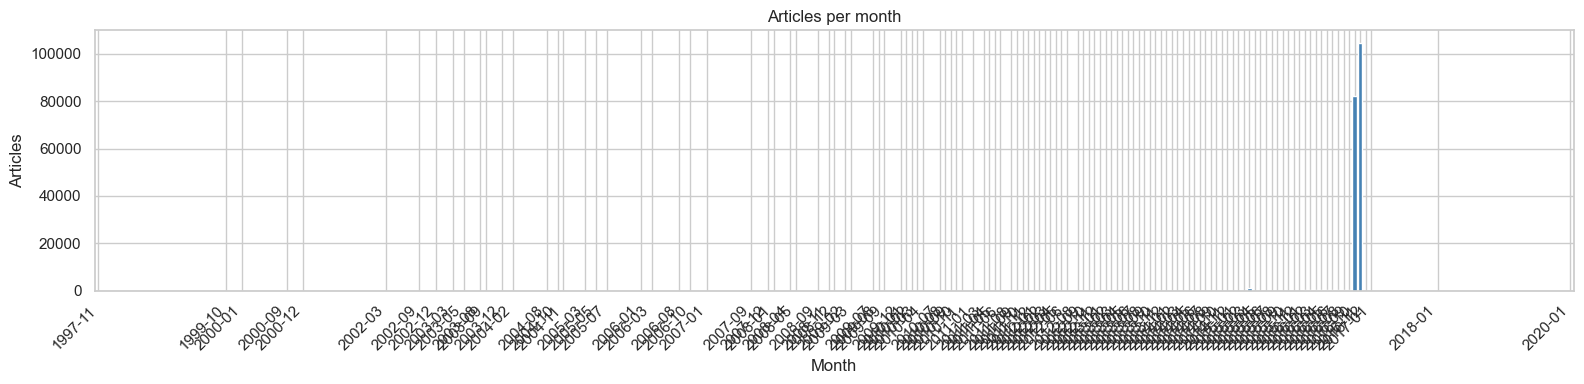

In [12]:
monthly = df.groupby(df["date"].dt.to_period("M")).size()
monthly.plot(kind="bar", figsize=(16, 4), color="steelblue", width=0.8)
plt.title("Articles per month")
plt.ylabel("Articles")
plt.xlabel("Month")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

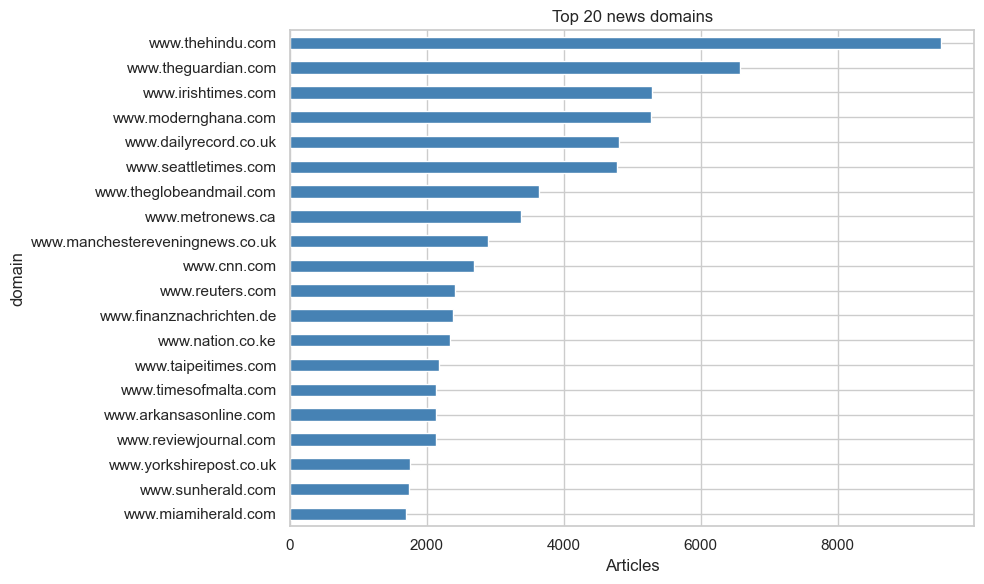


Total unique domains: 826


In [12]:
top_domains = df["domain"].value_counts().head(20)
top_domains.plot(kind="barh", figsize=(10, 6), color="steelblue")
plt.title("Top 20 news domains")
plt.xlabel("Articles")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print(f"\nTotal unique domains: {df['domain'].nunique():,}")

## 7. Headline Quote Detection

The thesis methodology requires articles whose **headline contains a direct quotation**. A headline qualifies if it contains at least one quoted span enclosed in:
- Straight double quotes `"..."`
- Curly double quotes `“...”`
- Single quotes `‘...’` — common in British outlets (Guardian, BBC, Telegraph) which use single quotes in headlines per house style

The single-quote pattern requires whitespace or punctuation as boundaries so that apostrophes inside words (`Biden’s`, `it’s`) are not matched.

**Implementation note:** the regexes use regular Python strings (not raw strings) so that `\u201c`-style escapes are resolved to actual Unicode characters by Python before being passed to `re`. Using raw strings (`r"..."`) causes `\u201c` to be treated as the literal characters `\`, `u`, `2`, `0`, `1`, `c` inside the character class, which incorrectly matches digits and common letters.

Body direct quotes are extracted for descriptive purposes only. The downstream cosine-similarity step matches headline quotes against body **sentences** rather than body quote spans, so contextomy cases where the body paraphrases rather than reproduces the headline quote are not excluded.

In [13]:
# Double-quoted spans: "..." or “...”
# Non-raw string: Python resolves \u201c to the actual Unicode curly-quote character.
DQUOTE_RE = re.compile(
    "[\"\u201c]([^\"\u201c\u201d]{20,300})[\"\u201d]"
)

# Single-quoted spans: '...' or ‘...’
# Boundary-aware: requires surrounding whitespace/punctuation so apostrophes
# inside words (Biden’s, it’s) are not matched.
SQUOTE_RE = re.compile(
    "(?:^|[\\s\\-\u2014\u2013:])['\u2018]([^'\u2018\u2019]{20,300})['\u2019](?=[\\s.,;:!?\\-\u2014\u2013]|$)"
)

def extract_quotes(text):
    """Return list of quoted spans (double- and single-quoted)."""
    if not isinstance(text, str):
        return []
    return DQUOTE_RE.findall(text) + SQUOTE_RE.findall(text)

df["title_quotes"]    = df["title"].apply(extract_quotes)
df["body_quotes"]     = df["text"].apply(extract_quotes)
df["n_title_quotes"]  = df["title_quotes"].str.len()
df["n_body_quotes"]   = df["body_quotes"].str.len()
df["has_title_quote"] = df["n_title_quotes"] > 0
df["has_body_quote"]  = df["n_body_quotes"]  > 0   # descriptive only

print(f"Articles with quoted headline       : {df['has_title_quote'].sum():,}  "
      f"({df['has_title_quote'].mean()*100:.1f}%)")
print(f"Articles with body direct quotes    : {df['has_body_quote'].sum():,}  "
      f"({df['has_body_quote'].mean()*100:.1f}%)")
print(f"  of headline-quoted, also body-quoted : "
      f"{(df['has_title_quote'] & df['has_body_quote']).sum():,}")

Articles with quoted headline       : 3,705  (1.9%)
Articles with body direct quotes    : 128,141  (67.3%)
  of headline-quoted, also body-quoted : 3,329


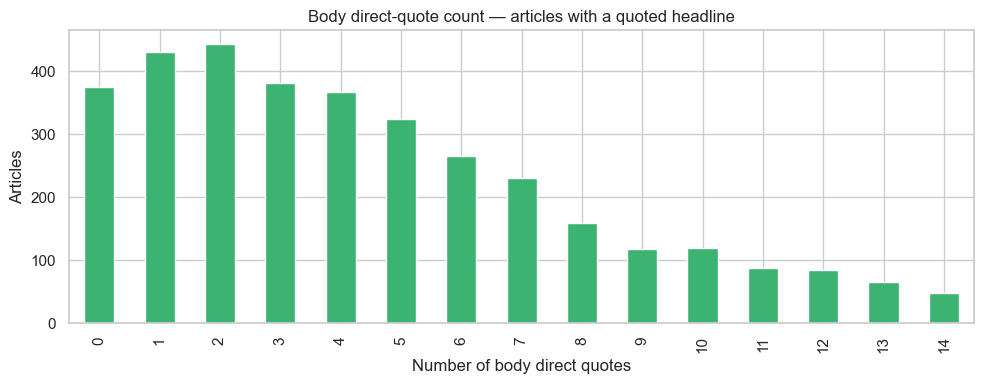

In [14]:
# Distribution of body-quote count among headline-quoted articles
subset = df[df["has_title_quote"]]
subset["n_body_quotes"].value_counts().sort_index().head(15).plot(
    kind="bar", figsize=(10, 4), color="mediumseagreen", edgecolor="white")
plt.title("Body direct-quote count — articles with a quoted headline")
plt.xlabel("Number of body direct quotes")
plt.ylabel("Articles")
plt.tight_layout()
plt.show()

In [14]:
# Sample: articles with a quoted headline — inspect title quote vs body quote count
sample_cols = ["title", "title_quotes", "n_body_quotes", "domain"]
df[df["has_title_quote"]][sample_cols].sample(10, random_state=0)

,title,title_quotes,n_body_quotes,domain
52621,‘IS militants kill civilians in central Afghanistan’,[IS militants kill civilians in central Afghanistan],2,www.thehindu.com
160574,'Teen raped my daughter before sex attack on beach',[Teen raped my daughter before sex attack on beach],7,www.dailypost.co.uk
148005,Jets' Fitzpatrick 'definitely optimistic' about playing,[definitely optimistic],9,www.kansas.com
108963,'Way out of the ordinary' times for tiny Victorian farming town,[Way out of the ordinary],20,www.abc.net.au
71025,Ontario premier calls inmate's 52-month segregation 'extremely disturbing' | Metro News,[extremely disturbing],12,www.metronews.ca
81817,"“Mummy bloggers have scared me off motherhood"": Radio announcer says",[Mummy bloggers have scared me off motherhood],3,www.gladstoneobserver.com.au
37616,'The Birth of a Nation' was an Oscar shoo-in. Before the rape scandal. | City Pages,[The Birth of a Nation],1,www.citypages.com
1880,'Those messages disappear all by themselves'; Hacked emails show Clinton aides suggesting jokes,[Those messages disappear all by themselves],11,www.torontosun.com
113855,Ministers will ‘fight in every capital’ to protect LGBT ‘watchdog’,[fight in every capital],4,www.yorkshirepost.co.uk
55300,Clerk’s Office Receives Concerns About Mailer on 'Social Security Referendum',[Social Security Referendum],1,www.csbj.com


## 8. Eligible Subset

Three criteria must all be satisfied for an article to enter the downstream pipeline:

1. **Headline contains a real direct quote** of at least `MIN_QUOTE_WORDS` words. The word-count floor ensures the quoted span carries enough semantic content for reliable cosine-similarity matching — single-word or two-word spans produce near-random embeddings.
2. **Body is non-trivially long** (≥ `MIN_BODY_WORDS` words) — enough surrounding context for the headline quote to be matched against, and enough text for an annotator to judge whether the headline quote faithfully represents the speaker's fuller statement.
3. **Source domain is a recognised political/general news outlet.** CC-News is an unmoderated general crawl and includes tech tutorials, crime briefs, sports results, and other content where contextomy is not a meaningful concept. Restricting to established outlets aligns the English test set with the journalistic context in which contextomy is theoretically meaningful, and parallels Song et al.’s focus on Korean political news.

The absence of body direct quotes is **not** a disqualifier. Contextomy cases where the body only paraphrases the headline quote are exactly the subtle distortion the methodology is designed to detect.

In [16]:
MIN_BODY_WORDS  = 50
MIN_QUOTE_WORDS = 4

DENY_DOMAINS = {
    "mirror.co.uk", "dailymail.co.uk", "thesun.co.uk",
    "inquisitr.com", "uproxx.com",
    "sputniknews.com", "breitbart.com", "israelnationalnews.com",
    "sott.net", "thehindu.com", "dailyrecord.co.uk"
}

eligible = df[
    df["has_title_quote"] &
    (df["body_len"] >= MIN_BODY_WORDS) &
    (df["title_quotes"].apply(
        lambda quotes: any(len(q.split()) >= MIN_QUOTE_WORDS for q in quotes)
    )) &
    (~df["domain_norm"].isin(DENY_DOMAINS))
].copy().reset_index(drop=True)

print(f"Eligible articles : {len(eligible):,}")
print(f"\nTop domains:")
print(eligible["domain_norm"].value_counts().head(20))
print(f"\nSample titles:")
for _, row in eligible.sample(min(10, len(eligible)), random_state=42).iterrows():
    print(f"  [{row['domain_norm']}] {row['title']}")
    print(f"   → {row['title_quotes']}")

Eligible articles : 2,452

Top domains:
domain_norm
theguardian.com                234
irishtimes.com                 160
cnn.com                         82
newsletter.co.uk                60
yorkshirepost.co.uk             55
coventrytelegraph.net           48
manchestereveningnews.co.uk     48
seattletimes.com                46
theborneopost.com               43
modernghana.com                 37
timesofmalta.com                35
theglobeandmail.com             33
scotsman.com                    30
dailypost.co.uk                 29
ottawasun.com                   25
reviewjournal.com               24
standard.co.uk                  23
ledger-enquirer.com             22
thenewstribune.com              21
metronews.ca                    21
Name: count, dtype: int64

Sample titles:
  [bridlingtonfreepress.co.uk] Regeneration boss expects ‘new and exciting use’ for legion site
   → ['new and exciting use']
  [coventrytelegraph.net] Jack McBean says he 'feels confident in front of goal'

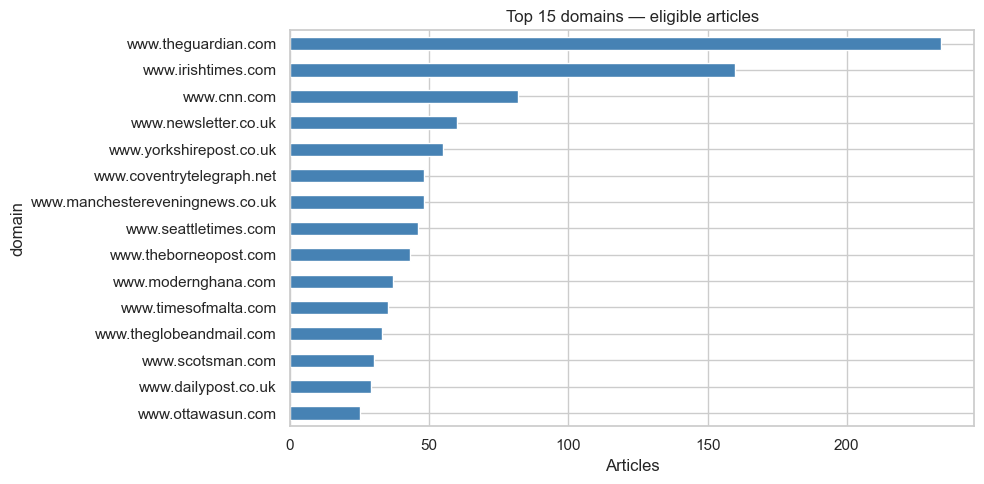

In [17]:
# Domain breakdown of eligible articles
eligible["domain"].value_counts().head(15).plot(
    kind="barh", figsize=(10, 5), color="steelblue")
plt.title("Top 15 domains — eligible articles")
plt.xlabel("Articles")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Save Eligible Subset

The eligible subset is saved to `data/cc_news_eligible.parquet` for the downstream headline↔body matching notebook. Quote lists are stored as native Python lists; Parquet preserves these as list-typed columns.

In [18]:
save_cols = ["title", "text", "domain", "date", "url",
             "title_quotes", "body_quotes",
             "n_title_quotes", "n_body_quotes",
             "has_body_quote",
             "title_len", "body_len"]

eligible_path = os.path.join(DATA_DIR, "cc_news_eligible.parquet")
eligible[save_cols].to_parquet(eligible_path, index=False)
size_mb = os.path.getsize(eligible_path) / 1e6
print(f"Saved eligible subset → {eligible_path}  ({size_mb:.1f} MB)")
print(f"Rows: {len(eligible):,}   Columns: {len(save_cols)}")

Saved eligible subset → data/cc_news_eligible.parquet  (6.2 MB)
Rows: 2,452   Columns: 12


## 10. Conclusions

This notebook prepares the English-language data foundation for the thesis. Key outcomes:

**Scale.** A streaming scan of CC-News yields a representative sample without requiring local storage of the full ~3 GB corpus. The eligible subset (quoted headline + ≥ 50 body words) is well above the 150–200 examples required for manual annotation and supports stratified sampling across domains and dates.

**Headline-quote coverage.** Catching both double- and single-quoted headline spans is important: British outlets use single quotes in headlines per house style and would otherwise be systematically excluded.

**Body matching design.** Body direct quotes are extracted descriptively but are not a filter criterion. The downstream matching step compares the headline quote against body sentences (regardless of whether they are quoted), capturing contextomy cases where the body paraphrases rather than reproduces the headline quote — a subtler and more challenging form of distortion than verbatim mismatch.

**Next steps.**
- `02_quote_matching.ipynb` — sentence-level cosine-similarity matching between headline quote and body, using a multilingual sentence transformer (`paraphrase-multilingual-mpnet-base-v2`) for parity with the Korean evaluation.
- `03_annotation.ipynb` — stratified sampling of ~200 articles for manual annotation of the English test set.
- `04_detection.ipynb` — zero-shot detection benchmarks: cosine similarity, multilingual NLI (mDeBERTa-MNLI), and LLM-as-a-judge (GPT-4).